<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
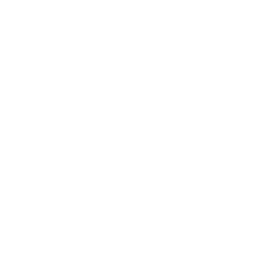
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Chemical Reactor Upset Diagnosis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identify variables driving reactor T2 exceedance during upset event &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A continuous stirred-tank reactor (CSTR) drifted into a thermal upset
when its coolant supply degraded. Under normal operation the coolant
flow, reactor temperature, and jacket temperature move together along a
single process-load axis. We build a three-component MVP model on
100 normal-operation observations, then score 100 upset observations
against it with `PROC MVPDIAGNOSE`. Decomposing Hotelling's
*T*-squared statistic into per-variable contributions isolates the
thermal-coupling trio — `jacket_temp`, `coolant_flow`, and
`reactor_temp` — as the variables driving the exceedance, pointing
operations straight at the coolant subsystem.

## Data Sources

| Dataset | Role | Observations |
|---|---|---|
| `reactor_normal` | Normal-operation training data for the MVP model | 100 |
| `reactor_upset` | Upset-event observations scored against the model | 100 |

The six measured variables are `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L), and `pressure` (bar).
Both datasets are simulated from a shared latent *process load* so the
normal data carries the same correlation structure a real CSTR exhibits;
the upset injects a coolant-supply loss that breaks that structure.

## Step 1 — Train the normal-operation MVP model

Normal running is governed by a latent process load: higher load pulls
coolant flow down while pushing reactor and jacket temperatures up.
`PROC MVPMODEL` extracts three principal components from the 100
normal observations and persists them with `OUTMODEL=` so the diagnosis
step can score new data against the same reference.

In [1]:
data reactor_normal;
  call streaminit(7);
  do t = 1 to 100;
    load = rand('normal', 0, 1);                 /* latent process load */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    output;
  end;
run;

proc mvpmodel data=reactor_normal outmodel=reactor_model;
  var reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
run;


                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882



NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Step 2 — Score the upset event and decompose *T*-squared

The upset cuts coolant flow by roughly 12 L/min while reactor and
jacket temperatures climb — the normal coolant/temperature coupling is
broken. `PROC MVPDIAGNOSE` scores each upset observation against the
reference model, writing the standardized scores and residuals to
`OUT=` and the per-variable *T*-squared contributions to `OUTCONTRIB=`.
Every observation lands far outside the control limit, confirming a
sustained multivariate excursion rather than isolated noise.

In [2]:
data reactor_upset;
  call streaminit(101);
  do t = 1 to 100;
    load = rand('normal', 0, 1);
    /* Coolant pump degrades: flow drops, temperatures run away */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    output;
  end;
run;

proc mvpdiagnose data=reactor_upset model=reactor_model
                 out=reactor_scores;
  var reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
run;


                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more




NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Step 3 — Rank the average contributions

`OUTCONTRIB=` writes one row per scored observation with a
`<variable>_CONTRIB` column for each process variable. Averaging those
columns gives each variable's mean contribution to the upset; a
transpose reshapes the one-row summary into a tidy variable/value table
that ranks the fault drivers.

In [3]:
proc means data=reactor_contrib mean noprint;
  var reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  output out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
run;

proc transpose data=contrib_means out=contrib_long name=metric;
  var mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
run;

/* Attach readable variable names and the mean-contribution value */
data contrib_ranked;
  set contrib_long;
  length variable $14;
  if      metric = 'mc_reactor_temp' then variable = 'reactor_temp';
  else if metric = 'mc_coolant_flow' then variable = 'coolant_flow';
  else if metric = 'mc_jacket_temp'  then variable = 'jacket_temp';
  else if metric = 'mc_feed_conc'    then variable = 'feed_conc';
  else if metric = 'mc_pressure'     then variable = 'pressure';
  mean_contrib = col1;
  keep variable mean_contrib;
run;

proc sort data=contrib_ranked;
  by descending mean_contrib;
run;

proc print data=contrib_ranked noobs;
  var variable mean_contrib;
run;


    VARIABLE   MEAN_CONTRIB
------------  -------------
jacket_temp   4177.66720283
coolant_flow  2882.19501987
reactor_temp  1602.04200377
pressure       280.73140863
feed_conc       61.43535437



NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/717a4e4d-9cca-4d36-b51b-f173e1987d07/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Step 4 — Contribution plot

The contribution plot makes the diagnosis immediate: the thermally
coupled trio — `jacket_temp`, `coolant_flow`, and `reactor_temp` —
dwarfs `feed_conc` and `pressure`, which barely register. The three
dominant bars are exactly the variables tied together by the coolant
loop, so the fault is unambiguously thermal, not a feed or pressure
problem.

NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


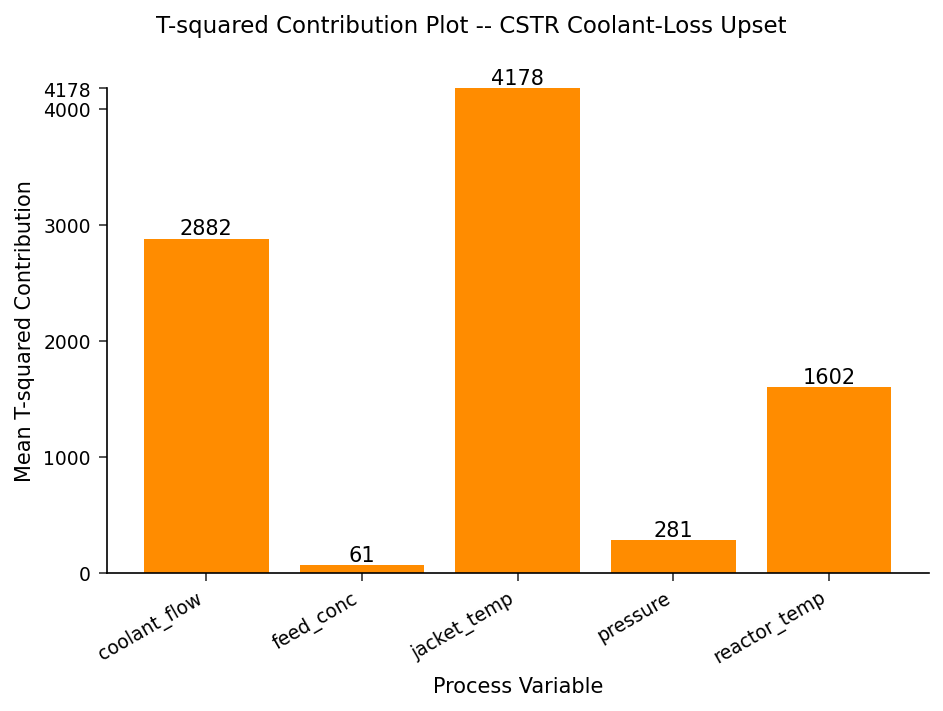

In [4]:
proc sgplot data=contrib_ranked;
  vbar variable / response=mean_contrib
                  fillattrs=(color=darkorange)
                  datalabel;
  xaxis label='Process Variable';
  yaxis label='Mean T-squared Contribution';
  title 'T-squared Contribution Plot -- CSTR Coolant-Loss Upset';
run;

## Step 5 — *T*-squared control timeline

Plotting each observation's *T*-squared against the model's control
limit shows the excursion is continuous: every upset observation sits
orders of magnitude above the limit reference line. There is no
recovery within the window, consistent with a hardware fault that
persists until the coolant subsystem is serviced.

NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


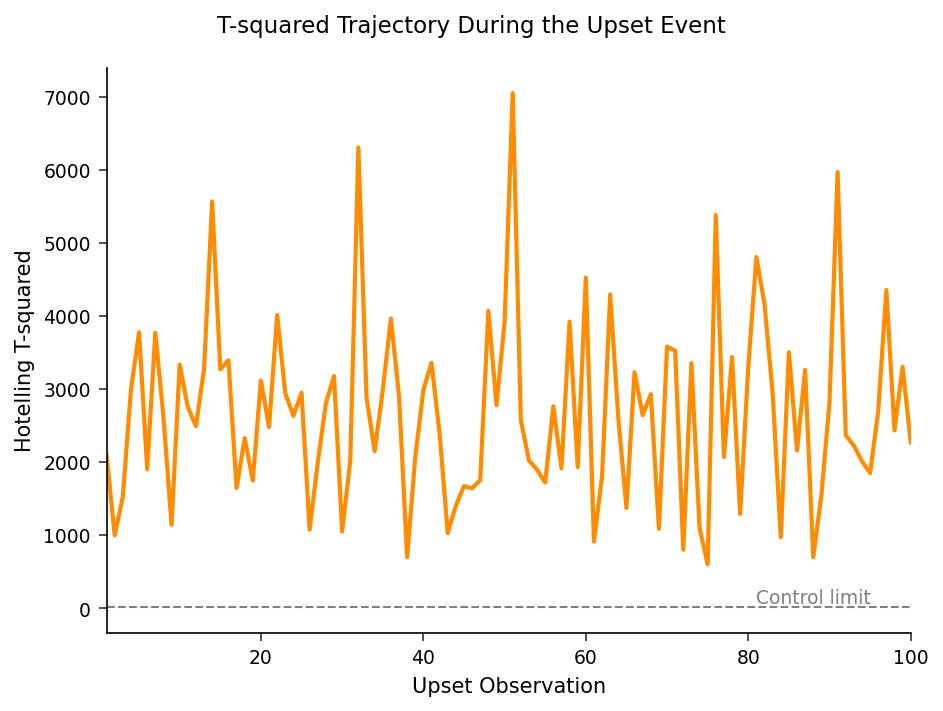

In [5]:
proc sgplot data=reactor_scores;
  series x=_OBS y=_TSQUARED / lineattrs=(color=darkorange thickness=2);
  refline 14.87 / axis=y
                  label='Control limit'
                  lineattrs=(pattern=dash color=gray);
  xaxis label='Upset Observation';
  yaxis label='Hotelling T-squared';
  title 'T-squared Trajectory During the Upset Event';
run;

## Findings &amp; Corrective Action

- **Top drivers**: `jacket_temp`, `coolant_flow`, and `reactor_temp`
  together account for essentially all of the *T*-squared signal; their
  mean contributions are two to three orders of magnitude above
  `feed_conc` and `pressure`.
- **Root cause**: a coolant-supply loss. `coolant_flow` is the only
  *manipulated* variable of the three — the temperature rises are
  downstream consequences of losing cooling, so the actionable fault is
  the coolant subsystem.
- **Control status**: all 100 upset observations breach the
  *T*-squared limit, indicating a sustained excursion rather than a
  transient.
- **Corrective action**: inspect and rebuild the coolant pump; add a
  redundant coolant-flow transmitter so a future supply loss is caught
  by univariate alarming before it propagates into the temperature
  loop.

## Export the ranked contributions

The ranked contribution table is written to CSV for the post-event
report and downstream dashboards.

In [6]:
proc export data=contrib_ranked
            outfile='reactor_upset_contributions.csv'
            dbms=csv replace;
run;

NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>